In [1]:
# Acquire normalization information
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.patches as patches
import matplotlib.colors as colors

# Geometric factors
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:3]
# Axial groups
axialgroupsL = {} # (x, y) position: list of channel IDs
axialgroupsR = {}
for n in range(3072):
    if (map[n, 0], map[n, 1]) not in axialgroupsR:
        axialgroupsR[(map[n, 0], map[n, 1])] = []
    axialgroupsR[(map[n, 0], map[n, 1])].append(n)
for n in range(3072, 6144):
    if (map[n, 0], map[n, 1]) not in axialgroupsL:
        axialgroupsL[(map[n, 0], map[n, 1])] = []
    axialgroupsL[(map[n, 0], map[n, 1])].append(n)
agIDlookupL = np.zeros(3072, dtype = np.int16)
agIDlookupR = np.zeros(3072, dtype = np.int16)
for entry in range(len(axialgroupsL)):
    for id in axialgroupsL[list(axialgroupsL.keys())[entry]]:
        agIDlookupL[id - 3072] = entry
for entry in range(len(axialgroupsR)):
    for id in axialgroupsR[list(axialgroupsR.keys())[entry]]:
        agIDlookupR[id] = entry
print(axialgroupsR)
print(agIDlookupR[0:20])
# Transaxial groups
transaxialgroupsL = {}
transaxialgroupsR = {}
for n in range(3072):
    if map[n, 2] not in transaxialgroupsR:
        transaxialgroupsR[map[n, 2]] = []
    transaxialgroupsR[map[n, 2]].append(n)
for n in range(3072, 6144):
    if map[n, 2] not in transaxialgroupsL:
        transaxialgroupsL[map[n, 2]] = []
    transaxialgroupsL[map[n, 2]].append(n)
tgIDlookupL = np.zeros(3072, dtype = np.int16)
tgIDlookupR = np.zeros(3072, dtype = np.int16)
for entry in range(len(transaxialgroupsL)):
    for id in transaxialgroupsL[list(transaxialgroupsL.keys())[entry]]:
        tgIDlookupL[id - 3072] = entry
for entry in range(len(transaxialgroupsR)):
    for id in transaxialgroupsR[list(transaxialgroupsR.keys())[entry]]:
        tgIDlookupR[id] = entry
print(transaxialgroupsR)
print(tgIDlookupR[0:20])
print(len(axialgroupsL), len(axialgroupsR), len(transaxialgroupsL), len(transaxialgroupsR))

# Heatmap utils
heatmapmin, heatmapmax = 0.8, 1.2
def setheatmapminmax(min, max):
    global heatmapmin, heatmapmax
    heatmapmin, heatmapmax = min, max
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]
mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)
ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)
ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)
scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))
for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i
for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072
def getcolor(value, cmap = 'RdBu_r', numdiscretecolors = 20):
        colormap = plt.get_cmap(cmap)
        if value < heatmapmin:
            return colormap(0.0)
        elif value > heatmapmax:
            return colormap(1.0)
        else:
            return colormap((value - heatmapmin) / (heatmapmax - heatmapmin) * (numdiscretecolors - 2) // 1 / (numdiscretecolors - 2))
def makeheatmap(countsIDorder,title, name, heatmapmin = 0.80, heatmapmax = 1.20):
    setheatmapminmax(heatmapmin, heatmapmax)
    heatmapL = np.zeros((32, 96))
    heatmapR = np.zeros((32, 96))
    for i in range(3072):
        index = np.where(scanner_arc_R == i)
        heatmapR[index] = countsIDorder[i]
    for i in range(3072, 6144):
        index = np.where(scanner_arc_L == i)
        heatmapL[index] = countsIDorder[i]
    heatmapR = heatmapR / np.median(heatmapR)
    heatmapL = heatmapL / np.median(heatmapL)
    #Dead cells
    for i in range(32):
        for j in range(96):
            if heatmapR[i, j] == 0:
                heatmapR[i, j] = -1
            if heatmapL[i, j] == 0:
                heatmapL[i, j] = -1

    face_dim = 3.2
    space = 1.2
    blank_color = 'black'
    cmap = plt.get_cmap('RdBu_r') # 'seismic' or 'RdBu' or 'rwb'
        
    fig, ax = plt.subplots(figsize = (8, 6))

    #rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
    #ax.add_patch(rect)

    # Plot R
    for z in range(32):
        zspace = z // 8 * space
        for y in range(96):
            yspace = y // 8 * space
            if heatmapR[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)

    # Plot L
    for z in range(32):
        zspace = z // 8 * space 
        for y in range(96):
            yspace = y // 8 * space
            if heatmapL[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)
    bounds = np.linspace(heatmapmin, heatmapmax, 21)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    diff = heatmapmax - heatmapmin
    cbar.set_ticks([heatmapmin, heatmapmin+diff*0.0, heatmapmin+diff*0.1, heatmapmin+diff*0.15, heatmapmin+diff*0.2, heatmapmin+diff*0.25, heatmapmin+diff*0.3, heatmapmin+diff*0.35, heatmapmin+diff*0.4, heatmapmin+diff*0.45, heatmapmin+diff*0.5, heatmapmin+diff*0.55, heatmapmin+diff*0.6, heatmapmin+diff*0.65, heatmapmin+diff*0.7, heatmapmin+diff*0.75, heatmapmin+diff*0.8, heatmapmin+diff*0.85, heatmapmin+diff*0.9, heatmapmin+diff*0.95, heatmapmax])
    cbar.set_ticklabels([
        '',
        #f'{heatmapmin:.2e}',
        f'{heatmapmin}',
        '', '', '', '', '', '', '', '',
        f'{heatmapmin+diff*0.5}',
        '', '', '', '', '', '', '', '', '',
        f'{heatmapmax}'
    ])
    plt.xlim(-2,322.4)
    pady = 36
    plt.ylim(-104.8 - pady, 113.2)
    plt.axis('off')
    #plt.tight_layout()
    plt.title(title)
    plt.savefig(os.path.join('plots', f'{name}heatmap.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

def makehist(eventcounts, eventcountsIDorder, title, fit = True):
    plt.figure(1, figsize = (6, 3))
    bins = np.linspace(0.8, 1.2, 200)
    plt.hist(eventcounts / np.median(eventcounts), bins = bins, color = 'red', label = 'Unnormalized', histtype = 'step', linewidth = 1)
    hist, bins = plt.hist(eventcountsIDorder / np.median(eventcountsIDorder), bins = bins, color = 'blue', label = 'Normalized', histtype = 'step', linewidth = 1)[0:2]
    def gaussian(x, a, mu, sigma):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
    if fit:
        bincenters = (bins[1:] + bins[:-1]) / 2
        popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [100, 1.0, 0.03])
        print(popt)
        plotting_bounds = np.linspace(popt[1] - 4 * popt[2], popt[1] + 4 * popt[2], 100)
        plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black', label = f'sigma = {np.abs(popt[2]):.4f}')
    plt.legend()
    plt.xlim(0.78,1.22)
    plt.xlabel('Channel activity (sum across LORs) scaled to median')
    plt.ylabel('Number of channels')
    plt.title(title)
    plt.show()

xedges = np.linspace(-180, 180, 361)
yedges = np.linspace(-180, 180, 361)
def siddon(x1, y1, x2, y2, x_edges, y_edges, count):
    dx = x2 - x1
    dy = y2 - y1
    total_length = np.hypot(dx, dy)
    alphas = [0.0, 1.0]
    if dx != 0:
        ax = (x_edges - x1) / dx
        alphas.extend(ax[(ax > 0) & (ax < 1)])
    if dy != 0:
        ay = (y_edges - y1) / dy
        alphas.extend(ay[(ay > 0) & (ay < 1)])
    alphas = np.unique(np.sort(alphas))
    contribution = np.zeros((len(x_edges) - 1, len(y_edges) - 1))
    for a0, a1 in zip(alphas[:-1], alphas[1:]):
        amid = (a0 + a1) / 2
        xmid = x1 + amid * dx
        ymid = y1 + amid * dy
        ix = np.searchsorted(x_edges, xmid) - 1
        iy = np.searchsorted(y_edges, ymid) - 1
        if (0 <= ix < len(x_edges) - 1 and 0 <= iy < len(y_edges) - 1):
            length = (a1 - a0) * total_length
            contribution[iy, ix] += length * count
    return contribution
def plot_img(img, fignum, name, title, roi = 360, vmin = 0.80, vmax = 1.20, save = False):
    plt.figure(fignum, figsize = (5, 5))
    norm_img = img #/ sensimg
    norm_img = np.flip(norm_img, axis = 0)
    if roi != 360:
        norm_img = norm_img[180 - roi // 2:180 + roi // 2, 180 - roi // 2:180 + roi // 2]
    norm_img = norm_img / np.mean(norm_img)
    max_pixel = np.unravel_index(np.argmax(norm_img), norm_img.shape)
    max_pos = (-180 + max_pixel[1], 180 - max_pixel[0])
    plt.imshow(norm_img, cmap = 'hot', aspect = 'auto', vmin = vmin, vmax = vmax, extent = [-roi/2, roi/2, -roi/2, roi/2])
    #plt.plot(max_pos[0], max_pos[1], 'ro', color = 'blue', markersize = 4, alpha = 0.5)
    if roi == 180:
        plt.xticks(np.linspace(-150, 150, 11))
        plt.yticks(np.linspace(-150, 150, 11))
    else:
        plt.xticks(np.arange(-(roi / 2) // 10*10, (roi / 2) // 10*10 + 0.0001, 10))
        plt.yticks(np.arange(-(roi / 2) // 10*10, (roi / 2) // 10*10 + 0.0001, 10))
        plt.xlim(-(roi / 2), (roi / 2))
        plt.ylim(-(roi / 2), (roi / 2))
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title(title)
    if save:
        pass
        #plt.savefig(os.path.join(save_dir, f'{name}.png'))
    return max_pos
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]
topring = map[map[:, 2] == np.max(map[:, 2])]
topringL = topring[topring[:, 0] < 0]
topringR = topring[topring[:, 0] > 0]
print(len(topringL), len(topringR), topring[0])
yL_to_idx = {y: idx for idx, y in enumerate(topringL[:, 1])}
yR_to_idx = {y: idx for idx, y in enumerate(topringR[:, 1])}

def lor_sensitivity(xL, yL, xR, yR):
    return 1 / ((xL - xR)**2 + (yL - yR)**2)
def lor_sensitivity(idL, idR):
    return 1 / ((map[idL + 3072][0] - map[idR][0])**2 + (map[idL + 3072][1] - map[idR][1])**2)
lor_sensitivities = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(3072)):
    for j in range(3072):
        lor_sensitivities[i, j] = np.sqrt(lor_sensitivity(i, j))


{(np.float64(117.3250734), np.float64(-120.1245968)): [0, 3, 7, 14, 16, 18, 20, 21, 108, 110, 112, 113, 119, 120, 124, 127, 896, 899, 903, 910, 912, 914, 916, 917, 1004, 1006, 1008, 1009, 1015, 1016, 1020, 1023], (np.float64(114.8917743), np.float64(-122.2028306)): [1, 8, 10, 15, 17, 19, 22, 23, 104, 106, 109, 111, 115, 116, 117, 118, 897, 904, 906, 911, 913, 915, 918, 919, 1000, 1002, 1005, 1007, 1011, 1012, 1013, 1014], (np.float64(112.4584752), np.float64(-124.2810643)): [2, 5, 12, 13, 24, 25, 26, 28, 101, 103, 105, 107, 114, 121, 123, 125, 898, 901, 908, 909, 920, 921, 922, 924, 997, 999, 1001, 1003, 1010, 1017, 1019, 1021], (np.float64(110.0251761), np.float64(-126.3592981)): [4, 6, 9, 11, 29, 30, 31, 32, 73, 75, 97, 98, 99, 100, 122, 126, 900, 902, 905, 907, 925, 926, 927, 928, 969, 971, 993, 994, 995, 996, 1018, 1022], (np.float64(107.5918771), np.float64(-128.4375319)): [27, 33, 34, 35, 36, 38, 58, 62, 66, 68, 91, 93, 94, 95, 96, 102, 923, 929, 930, 931, 932, 934, 954, 958, 962

100%|██████████| 3072/3072 [00:24<00:00, 123.25it/s]


In [25]:
# Component-based normalization
#name = 'hcenter_pcut_a'
name = 'hcircpgd'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/{name}.bin'
num_cols, data_size = 4, 2
num_rows = os.path.getsize(path) // (num_cols * data_size)
data1 = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))
eventcounts = np.zeros((3072, 3072), dtype = np.float32)
axialpairs = np.zeros((96, 96), dtype = np.int32)
transaxialpairs = np.zeros((32, 32), dtype = np.int32)
normfactorsL = np.fromfile('normfactors/it9L.bin', dtype = np.float32)
normfactorsR = np.fromfile('normfactors/it9R.bin', dtype = np.float32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    if num_cols == 3:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    elif num_cols == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(axialpairs, (agIDlookupL[idls], agIDlookupL[idrs]), 1)
    np.add.at(transaxialpairs, (tgIDlookupL[idls], tgIDlookupL[idrs]), 1)
    #np.add.at(eventcounts, (idls, idrs), lor_sensitivities[idls, idrs])
    np.add.at(eventcounts, (idls, idrs), 1)
print(np.sum(eventcounts))
eventcountsIDorder = np.concatenate((eventcounts.sum(axis = 0), eventcounts.sum(axis = 1)), axis = 0)
efficiencies = eventcountsIDorder
efficiencies[efficiencies == 0] = 1
efficiencies = 1 / efficiencies
#efficiencies = efficiencies / np.mean(efficiencies)
print(efficiencies, np.sum(efficiencies))
gaxial = 1 / axialpairs
gtrans = 1 / transaxialpairs

Event counts: 100%|██████████| 20/20 [00:02<00:00,  8.04it/s]

1.9704008e+07
[0.00013714 0.00013732 0.0001296  ... 0.00013493 0.0001291  0.00010595] 8.011471


In [622]:
# Write to file
towrite = np.zeros((3072, 3072), dtype = np.float32)
for i in range(3072):
    for j in range(3072):
        towrite[i, j] = axialpairs[agIDlookupL[i], agIDlookupL[j]] * transaxialpairs[tgIDlookupL[i], tgIDlookupL[j]]
towrite = 1 / towrite
towrite = towrite / np.mean(towrite)
with open('normfactors.bin', 'wb') as f:
    towrite.tofile(f)


In [26]:
# Apply normalization per LOR
name = 'hcircpgd'
#name = 'hcirc_pcut_a'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/{name}.bin'
num_cols, data_size = 4, 2
stride = 1
num_rows = os.path.getsize(path) // (num_cols * data_size)
data2 = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))
acceptancetable = np.fromfile('acceptancetable.bin', dtype = np.bool).reshape(3072, 3072)
eventcountsperLOR1 = np.zeros((3072, 3072), dtype = np.float32)
eventcountsperLOR2 = np.zeros((3072, 3072), dtype = np.float32)
eventcountsperLOR3 = np.zeros((3072, 3072), dtype = np.float32)
eventcountsperLOR4 = np.zeros((3072, 3072), dtype = np.float32)
eventcountsperLOR5 = np.zeros((3072, 3072), dtype = np.float32)
eventcountsperLOR6 = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data2[i:i+1000000][::stride]
    if num_cols == 3:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    elif num_cols == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(eventcountsperLOR1, (idls, idrs), 1)
    np.add.at(eventcountsperLOR2, (idls, idrs), efficiencies[idls + 3072] * efficiencies[idrs])
    np.add.at(eventcountsperLOR3, (idls, idrs), efficiencies[idls + 3072] * efficiencies[idrs] * gaxial[agIDlookupL[idls], agIDlookupL[idrs]] * gtrans[tgIDlookupL[idls], tgIDlookupL[idrs]])
    np.add.at(eventcountsperLOR4, (idls, idrs), gaxial[agIDlookupL[idls], agIDlookupL[idrs]] * gtrans[tgIDlookupL[idls], tgIDlookupL[idrs]])
    np.add.at(eventcountsperLOR5, (idls, idrs), gaxial[agIDlookupL[idls], agIDlookupL[idrs]] * gtrans[tgIDlookupL[idls], tgIDlookupL[idrs]] / (normfactorsL[idls] * normfactorsR[idrs]))
    np.add.at(eventcountsperLOR6, (idls, idrs), acceptancetable[idls, idrs] * gaxial[agIDlookupL[idls], agIDlookupL[idrs]] * gtrans[tgIDlookupL[idls], tgIDlookupL[idrs]] / (normfactorsL[idls] * normfactorsR[idrs]))
print(np.sum(eventcountsperLOR1), np.sum(eventcountsperLOR2), np.sum(eventcountsperLOR3), np.sum(eventcountsperLOR4))
#eventcountsperLOR1 = eventcountsperLOR1 * acceptancetable
#eventcountsperLOR2 = eventcountsperLOR2 * acceptancetable
#eventcountsperLOR3 = eventcountsperLOR3 * acceptancetable
#eventcountsperLOR4 = eventcountsperLOR4 * acceptancetable
#eventcountsperLOR5 = eventcountsperLOR5 * acceptancetable
#eventcountsperLOR6 = eventcountsperLOR6 * acceptancetable
eventcountsuniquepos1 = np.zeros((len(topringL), len(topringR)), dtype = np.float32)
eventcountsuniquepos2 = np.zeros((len(topringL), len(topringR)), dtype = np.float32)
eventcountsuniquepos3 = np.zeros((len(topringL), len(topringR)), dtype = np.float32)
eventcountsuniquepos4 = np.zeros((len(topringL), len(topringR)), dtype = np.float32)
eventcountsuniquepos5 = np.zeros((len(topringL), len(topringR)), dtype = np.float32)
eventcountsuniquepos6 = np.zeros((len(topringL), len(topringR)), dtype = np.float32)
img1, img2, img3, img4, img5, img6 = np.zeros((360, 360)), np.zeros((360, 360)), np.zeros((360, 360)), np.zeros((360, 360)), np.zeros((360, 360)), np.zeros((360, 360))
for i in tqdm(range(3072)):
    yL = map[i + 3072][1]
    topringidL = yL_to_idx.get(yL)
    for j in range(3072):
        yR = map[j][1]
        topringidR = yR_to_idx.get(yR)
        eventcountsuniquepos1[topringidL, topringidR] += eventcountsperLOR1[i, j]
        eventcountsuniquepos2[topringidL, topringidR] += eventcountsperLOR2[i, j]
        eventcountsuniquepos3[topringidL, topringidR] += eventcountsperLOR3[i, j]
        eventcountsuniquepos4[topringidL, topringidR] += eventcountsperLOR4[i, j]
        eventcountsuniquepos5[topringidL, topringidR] += eventcountsperLOR5[i, j]
        eventcountsuniquepos6[topringidL, topringidR] += eventcountsperLOR6[i, j]
for row in tqdm(range(96)):
    for col in range(96):
        #img1 += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos1[row, col])
        #img2 += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos2[row, col])
        #img3 += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos3[row, col])
        img4 += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos4[row, col])
        img5 += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos5[row, col])
        #img6 += siddon(topringL[row][0], topringL[row][1], topringR[col][0], topringR[col][1], xedges, yedges, eventcountsuniquepos6[row, col])
eventcountsIDorder1 = np.concatenate((eventcountsperLOR1.sum(axis = 0), eventcountsperLOR1.sum(axis = 1)), axis = 0)
eventcountsIDorder2 = np.concatenate((eventcountsperLOR2.sum(axis = 0), eventcountsperLOR2.sum(axis = 1)), axis = 0)
eventcountsIDorder3 = np.concatenate((eventcountsperLOR3.sum(axis = 0), eventcountsperLOR3.sum(axis = 1)), axis = 0)
eventcountsIDorder4 = np.concatenate((eventcountsperLOR4.sum(axis = 0), eventcountsperLOR4.sum(axis = 1)), axis = 0)
eventcountsIDorder5 = np.concatenate((eventcountsperLOR5.sum(axis = 0), eventcountsperLOR5.sum(axis = 1)), axis = 0)
eventcountsIDorder6 = np.concatenate((eventcountsperLOR6.sum(axis = 0), eventcountsperLOR6.sum(axis = 1)), axis = 0)
print(eventcountsIDorder1, eventcountsIDorder1.shape)

Event counts:   0%|          | 0/20 [00:00<?, ?it/s]

Event counts: 100%|██████████| 20/20 [00:06<00:00,  3.16it/s]


1.9704008e+07 0.4778462 1.2399113e-08 0.4789698


100%|██████████| 96/96 [00:17<00:00,  5.38it/s]


[7292. 7282. 7716. ... 7411. 7746. 9438.] (6144,)


In [12]:
def sensmult(xL, yL, xR, yR):
    return 1 / ((xL - xR)**2 + (yL - yR)**2)
sensimg = np.zeros((360, 360))
for i in tqdm(range(96)):
    for j in range(96):
        sensimg += siddon(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1], xedges, yedges, 1)
        #sensimg += siddon(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1], xedges, yedges, sensmult(topringL[i][0], topringL[i][1], topringR[j][0], topringR[j][1]))
sensimg[sensimg == 0] = 1

100%|██████████| 96/96 [00:08<00:00, 10.80it/s]


(np.int64(-175), np.int64(147))

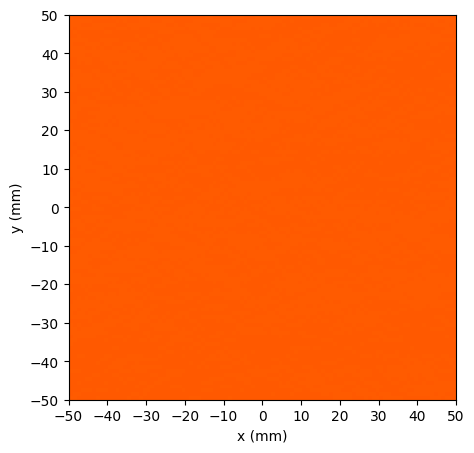

In [13]:
#plot_img(img1 / sensimg , 0 ,'', '', roi = 100, vmin = 0.9, vmax = 1.1)
plot_img(img4 / sensimg, 1 ,'', '', roi = 100, vmin = 0.9, vmax = 1.1)

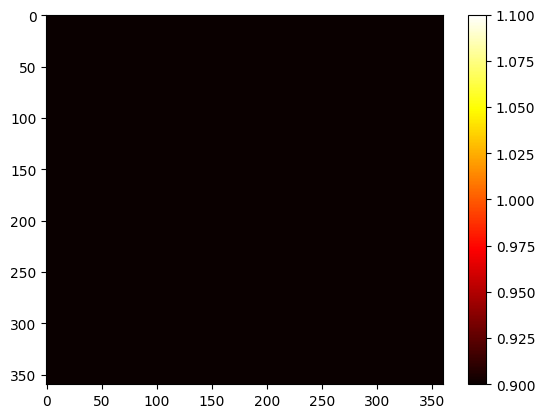

In [644]:
plt.imshow(img4 / sensimg, cmap = 'hot', aspect = 'auto', vmin = 0.9, vmax = 1.1)
plt.colorbar()
plt.show()

(100, 100)


/tmp/ipykernel_19407/4009597981.py:10: RuntimeWarning: invalid value encountered in divide
  plt.hist((imagecorrected1 / np.mean(imagecorrected1)).flatten(), bins = bins, color = 'red', alpha = 0.5, histtype = 'step', label = 'Unnormalized')
/home/kale-chen/.pyenv/versions/3.12.3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/kale-chen/.pyenv/versions/3.12.3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


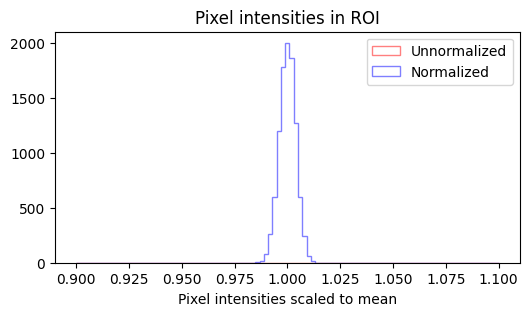

In [95]:
bins = np.linspace(0.9, 1.1, 100)
imgcorrected1 = img1 / sensimg
imgcorrected4 = img5 / sensimg
roi = 100
imagecorrected1 = imgcorrected1[180 - roi // 2:180 + roi // 2, 180 - roi // 2:180 + roi // 2]
imagecorrected4 = imgcorrected4[180 - roi // 2:180 + roi // 2, 180 - roi // 2:180 + roi // 2]
print(imagecorrected1.shape)

plt.figure(figsize = (6, 3))
plt.hist((imagecorrected1 / np.mean(imagecorrected1)).flatten(), bins = bins, color = 'red', alpha = 0.5, histtype = 'step', label = 'Unnormalized')
plt.hist((imagecorrected4 / np.mean(imagecorrected4)).flatten(), bins = bins, color = 'blue', alpha = 0.5, histtype = 'step', label = 'Normalized')
plt.xlim(bins[0] - 0.01, bins[-1] + 0.01)
plt.legend()
plt.xlabel('Pixel intensities scaled to mean')
plt.title('Pixel intensities in ROI')
plt.show()

[ 9.05296678e+02  9.99858096e-01 -5.00625054e-03]


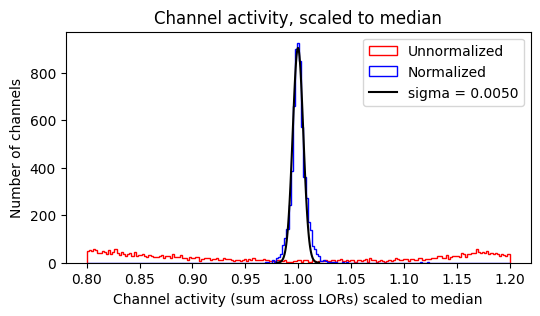

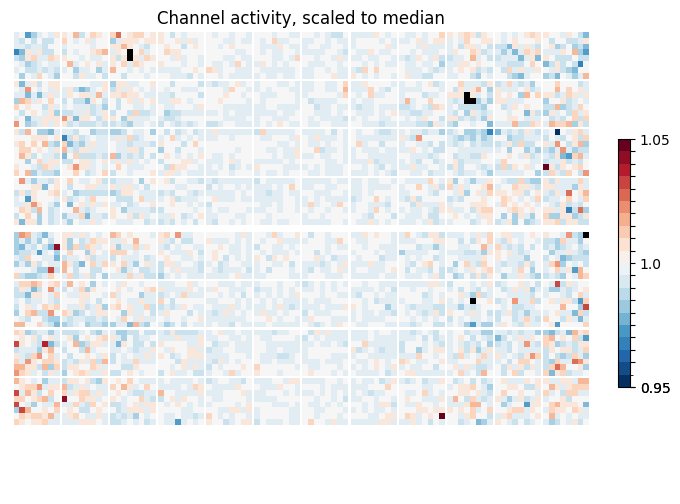

In [27]:
makehist(eventcountsIDorder, eventcountsIDorder5, 'Channel activity, scaled to median', fit = True)
makeheatmap(eventcountsIDorder5, 'Channel activity, scaled to median', 'noncorrectednogeom',0.95, 1.05)

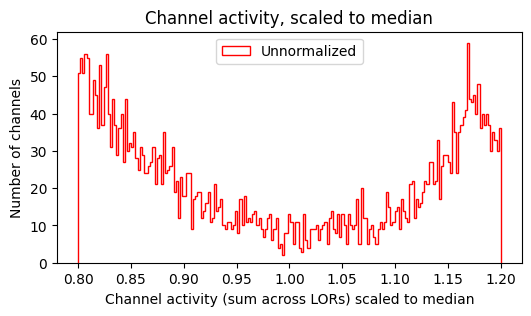

In [8]:
plt.figure(1, figsize = (6, 3))
bins = np.linspace(0.8, 1.2, 200)
plt.hist(eventcountsIDorder / np.median(eventcountsIDorder), bins = bins, color = 'red', label = 'Unnormalized', histtype = 'step', linewidth = 1)
plt.legend()
plt.xlim(0.78,1.22)
plt.xlabel('Channel activity (sum across LORs) scaled to median')
plt.ylabel('Number of channels')
plt.title('Channel activity, scaled to median')
plt.show()

100%|██████████| 3072/3072 [00:07<00:00, 430.15it/s]


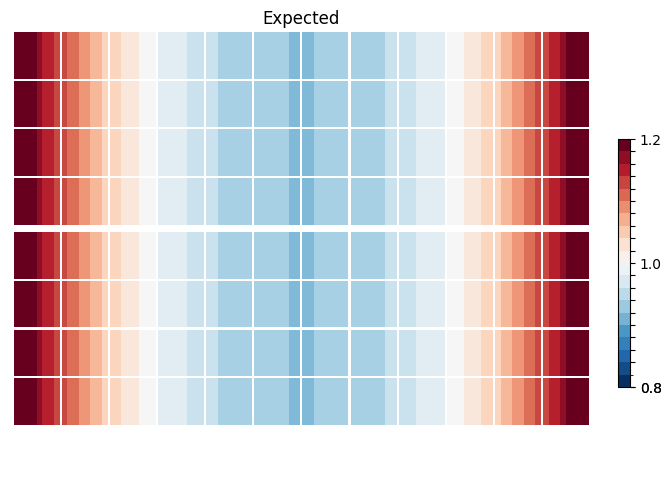

In [551]:
def lor_sensitivity(xL, yL, xR, yR):
    return 1 / ((xL - xR)**2 + (yL - yR)**2)
    #return 1
eventcountsExpected = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(3072)):
    for j in range(3072):
        eventcountsExpected[i, j] = lor_sensitivity(map[i + 3072][0], map[i + 3072][1], map[j][0], map[j][1])
eventcountsExpectedIDorder = np.concatenate((eventcountsExpected.sum(axis = 0), eventcountsExpected.sum(axis = 1)), axis = 0)
#makehist(eventcountsExpectedIDorder, eventcountsExpectedIDorder / np.median(eventcountsExpectedIDorder), 'Scatter/random corrected, scaled to median')
makeheatmap(eventcountsExpectedIDorder, 'Expected', 'noncorrectednogeom',0.80, 1.20)


In [26]:
def solve_intersections(xL, yL, xR, yR, r = 135):
    dx, dy = xR - xL, yR - yL
    A = dx**2 + dy**2
    B = 2 * (xL * dx + yL * dy)
    C = xL**2 + yL**2 - r**2
    discriminant = B**2 - 4*A*C
    if discriminant < 0:
        # No real intersections
        return []
    elif discriminant == 0:
        t = -B / (2*A)
        intersection1 = (xL + t*dx, yL + t*dy)
        return [intersection1]
    else:
        sqrt_disc = np.sqrt(discriminant)
        t1 = (-B + sqrt_disc) / (2*A)
        t2 = (-B - sqrt_disc) / (2*A)
        intersection1 = (xL + t1*dx, yL + t1*dy)
        intersection2 = (xL + t2*dx, yL + t2*dy)
        return [intersection1, intersection2]
def distance(xL, yL, xR, yR):
    return np.sqrt((xL - xR)**2 + (yL - yR)**2)
def quickplot(x, y, color):
    print(round(x, 3), round(y, 3))
    plt.scatter(x, y, color = color)
angles = []
counts = []
rdists = []
posL = list(axialgroupsL.keys())
posR = list(axialgroupsR.keys())
for i in range(96):
    xL, yL = posL[i]
    #quickplot(xL, yL, 'red')
    angleL = np.arctan2(yL, xL)
    angleL = angleL + 2 * np.pi if angleL < 0 else angleL
    angleL -= np.pi
    for j in range(96):
        xR, yR = posR[j]
        #quickplot(xR, yR, 'blue')
        try:
            in1, in2 = solve_intersections(xL, yL, xR, yR)
            #quickplot(in1[0], in1[1], 'green')
            #quickplot(in2[0], in2[1], 'green')
            restrictivedistance = max(distance(xL, yL, in1[0], in1[1]), distance(xL, yL, in2[0], in2[1]))
            rdists.append(restrictivedistance)
            angleR = np.arctan2(yR, xR)
            angle = angleL - angleR
            angles.append(angle)
            counts.append(axialpairs[i, j])
        except:
            pass


3910.88


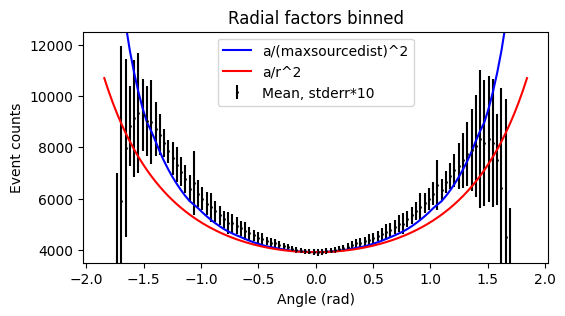

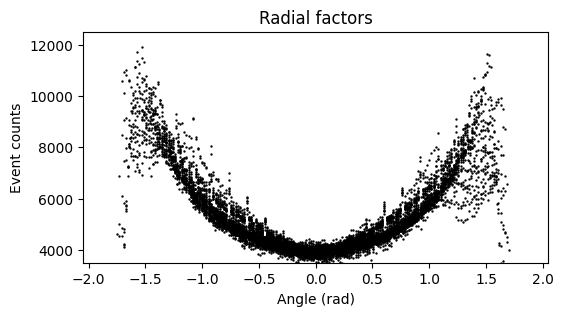

In [27]:
rdists = rdists / np.max(rdists)
geomdata = np.array([angles, counts, rdists])
num_bins, exaggeratestd = 100, 10
bins = np.linspace(np.min(geomdata[0]), np.max(geomdata[0]), num_bins + 1)
bin_indices = np.digitize(geomdata[0], bins) - 1  # bin_indices takes values 0 to num_bins-1

mean_counts = []
std_counts = []
mean_rdists = []
bin_centers = []
for b in range(num_bins):
    mask = bin_indices == b
    if np.any(mask):
        mean_counts.append(np.mean(geomdata[1][mask]))
        std_counts.append(np.std(geomdata[1][mask]) / np.sqrt(np.sum(mask)) * exaggeratestd)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
        mean_rdists.append(np.mean(geomdata[2][mask]))
    else:
        mean_counts.append(np.nan)
        std_counts.append(np.nan)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
        mean_rdists.append(np.nan)
mean_counts = np.array(mean_counts)
std_counts = np.array(std_counts)
bin_centers = np.array(bin_centers)
mean_rdists = np.array(mean_rdists)

# Plot mean and deviation as errorbars
plt.figure(figsize = (6, 3))
plt.errorbar(bin_centers, mean_counts, yerr=std_counts, fmt='o',
label = 'Mean, stderr*10', color='black', markersize = 1)
print(mean_counts[len(bin_centers) // 2])
plt.plot(bin_centers, 3910/mean_rdists**2, color = 'blue', label = 'a/(maxsourcedist)^2')
plt.plot(bin_centers, 7820/(1 - np.cos(np.pi - bin_centers)), color = 'red', label = 'a/r^2')
plt.legend()
plt.xlabel('Angle (rad)')
plt.ylabel('Event counts')
plt.title('Radial factors binned')
#plt.yscale('log')
plt.ylim(3500, 12500)
plt.show()
plt.figure(1, figsize = (6, 3))
plt.scatter(geomdata[0], geomdata[1], s = 0.5, color = 'black')
plt.ylim(3500, 12500)
plt.xlabel('Angle (rad)')
plt.ylabel('Event counts')
plt.title('Radial factors')
plt.show()

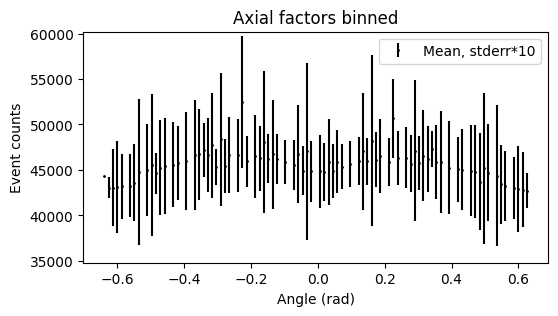

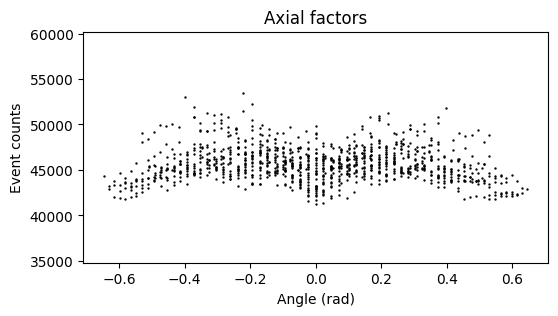

In [ ]:
zdiffs = []
counts = []
posL = list(transaxialgroupsL.keys())
posR = list(transaxialgroupsR.keys())
for i in range(32):
    zL = posL[i]
    for j in range(32):
        zR = posR[j]
        zdiffs.append(np.arctan2((zL - zR), 135))
        counts.append(transaxialpairs[i, j])
zdiffs, counts = np.array(zdiffs), np.array(counts)
geomdata = np.array([zdiffs, counts])
num_bins, exaggeratestd = 100, 10
bins = np.linspace(np.min(geomdata[0]), np.max(geomdata[0]), num_bins + 1)
bin_indices = np.digitize(geomdata[0], bins) - 1  # bin_indices takes values 0 to num_bins-1

mean_counts = []
std_counts = []
bin_centers = []
for b in range(num_bins):
    mask = bin_indices == b
    if np.any(mask):
        mean_counts.append(np.mean(geomdata[1][mask]))
        std_counts.append(np.std(geomdata[1][mask]) / np.sqrt(np.sum(mask)) * exaggeratestd)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
    else:
        mean_counts.append(np.nan)
        std_counts.append(np.nan)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
mean_counts = np.array(mean_counts)
std_counts = np.array(std_counts)
bin_centers = np.array(bin_centers)

plt.figure(figsize = (6, 3))
plt.errorbar(bin_centers, mean_counts, yerr=std_counts, fmt='o',
label = 'Mean, stderr*10', color='black', markersize = 1)
plt.xlabel('Angle (rad)')
plt.ylabel('Event counts')
plt.title('Axial factors binned')
plt.ylim(34800,60200)
plt.legend()
plt.show()
plt.figure(1, figsize = (6, 3))
plt.scatter(geomdata[0], geomdata[1], s = 0.5, color = 'black')
plt.xlabel('Angle (rad)')
plt.ylabel('Event counts')
plt.title('Axial factors')
plt.ylim(34800,60200)
plt.show()

In [ ]:
event